# 🎯 Targeted K-Fold Hyperparameter Tuning — mmBERT-small (Skenario 2)

Fine-tuning `jhu-clsp/mmBERT-small` (ModernBERT ~560M params) dengan  
**Targeted K-Fold Cross Validation** pada dua HP paling kritis.

---

## ⚠️ Perbedaan mmBERT-small vs DistilBERT

| Aspek | DistilBERT | mmBERT-small |
|---|---|---|
| Arsitektur | BERT klasik | **ModernBERT** |
| Ukuran | ~66M params | ~560M params |
| VRAM (bs=8) | ~3GB | ~8GB |
| batch_size aman | 8–32 | **4–8 saja** |
| Fix khusus | Tidak perlu | `CUDA_VISIBLE_DEVICES="0"` + `dynamo.disable` + `st==3.3.1` |

---

## 🎯 Grid yang Dituning

| HP | Nilai | Alasan |
|---|---|---|
| `learning_rate` | 1e-5, 2e-5, 3e-5, 5e-5 | Distribusi gradien berubah dengan data 2× |
| `epochs` | 2, 3, 4, 6 | Titik konvergensi optimal dengan data baru |

**HP dikunci:**

| HP | Nilai | Alasan |
|---|---|---|
| `batch_size` | 8 | bs=16 OOM di T4, bs=8 terbukti aman |
| `warmup_ratio` | 0.10 | Nilai robust untuk semua ukuran dataset |
| `max_seq_length` | 128 | Bergantung panjang teks, bukan jumlah data |

---

## ⏱️ Estimasi Waktu

- **4 × 4 = 16 kombinasi** × 5 fold = **80 run**
- mmBERT-small lebih besar dari DistilBERT → setiap run ≈ **5–8 menit**
- Total estimasi: **~7–10 jam** GPU Kaggle T4

---

## ✅ Validitas Data

- Training & validasi K-Fold: `triplets_valid_jhpolo_10.csv`
- Evaluasi akhir: `queries_indo.csv` + `qrels.csv` (file berbeda, query berbeda)
- **Tidak ada data leakage** ✅

---
## Cell 1 — Fix & Import Library

Tiga fix **wajib** untuk mmBERT-small (ModernBERT) di Kaggle:

1. **`CUDA_VISIBLE_DEVICES="0"`** — paksa single GPU, cegah DataParallel yang konflik dengan ModernBERT
2. **`torch._dynamo.config.disable = True`** — nonaktifkan torch.compile internal ModernBERT
3. **`sentence-transformers==3.3.1`** — downgrade dari 3.4.1 yang punya bug `_nested_gather`

Ketiganya harus dijalankan **sebelum** model diload.

In [1]:
# ============================================================
# FIX #1 — Paksa single GPU (WAJIB untuk ModernBERT)
# Harus sebelum import torch agar efektif
# ============================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# ============================================================
# FIX #2 — Downgrade sentence-transformers (WAJIB)
# Versi 3.4.1 punya bug _nested_gather yang crash saat logging
# ============================================================
import subprocess
subprocess.run(["pip", "install", "-q", "sentence-transformers==3.3.1"], check=True)
print("✅ sentence-transformers==3.3.1 terinstall.")

# ============================================================
# FIX #3 — Nonaktifkan torch.compile/dynamo (WAJIB untuk ModernBERT)
# ============================================================
import torch
import torch._dynamo
torch._dynamo.config.disable = True

import sys, math, json, warnings, importlib
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import KFold
import sentence_transformers
importlib.reload(sentence_transformers)
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

print(f"sentence-transformers : {sentence_transformers.__version__}")
print(f"PyTorch               : {torch.__version__}")
print(f"GPU tersedia          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU aktif             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"dynamo disabled       : {torch._dynamo.config.disable}")
print(f"CUDA_VISIBLE_DEVICES  : {os.environ.get('CUDA_VISIBLE_DEVICES')}")
print("\n✅ Semua fix aktif. Siap untuk mmBERT-small.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.2 MB/s eta 0:00:00
✅ sentence-transformers==3.3.1 terinstall.


2026-03-10 12:15:26.830989: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773144927.187831      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773144927.297990      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773144928.220147      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773144928.220194      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773144928.220197      55 computation_placer.cc:177] computation placer alr

sentence-transformers : 3.3.1
PyTorch               : 2.9.0+cu126
GPU tersedia          : True
GPU aktif             : Tesla T4
VRAM total            : 15.6 GB
dynamo disabled       : True
CUDA_VISIBLE_DEVICES  : 0

✅ Semua fix aktif. Siap untuk mmBERT-small.


---
## Cell 2 — Clone Repository & Setup Path

Output dipisah dari hasil DistilBERT agar tidak bentrok:
- `RESULTS_PATH` → `hp_targeted_kfold_mmbert_small/`
- `BEST_MODEL_PATH` → `best_model_mmbert_small_targeted/`

In [2]:
if os.path.exists("skripsi-clir-code"):
    print("Repository ditemukan. Pull...")
    !cd skripsi-clir-code && git pull
else:
    print("Cloning repository...")
    !git clone https://github.com/syifaurrr/skripsi-clir-code.git

REPO_PATH        = "./skripsi-clir-code"
SRC_PATH         = os.path.join(REPO_PATH, "src")
TRAIN_DATA_PATH  = os.path.join(REPO_PATH, "data", "training", "triplets_valid_jhpolo_10.csv")
RESULTS_PATH     = "./hp_targeted_kfold_mmbert_small"
BEST_MODEL_PATH  = "./best_model_mmbert_small_targeted"
RESULTS_LOG_FILE = os.path.join(RESULTS_PATH, "all_results.json")

sys.path.append(SRC_PATH)
os.makedirs(RESULTS_PATH, exist_ok=True)
os.makedirs(BEST_MODEL_PATH, exist_ok=True)

print(f"\nPath Training Data : {TRAIN_DATA_PATH}")
print(f"Path Hasil Tuning  : {RESULTS_PATH}")
print(f"Path Model Terbaik : {BEST_MODEL_PATH}")

Cloning repository...
Cloning into 'skripsi-clir-code'...
remote: Enumerating objects: 1051, done.
remote: Counting objects: 100% (1051/1051), done.
remote: Compressing objects: 100% (970/970), done.
remote: Total 1051 (delta 142), reused 985 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (1051/1051), 4.74 MiB | 14.52 MiB/s, done.
Resolving deltas: 100% (142/142), done.

Path Training Data : ./skripsi-clir-code/data/training/triplets_valid_jhpolo_10.csv
Path Hasil Tuning  : ./hp_targeted_kfold_mmbert_small
Path Model Terbaik : ./best_model_mmbert_small_targeted


---
## Cell 3 — Load Dataset

Dataset training dimuat penuh. Pembagian fold dilakukan dinamis di dalam `run_kfold()`.

> **Catatan validitas:** `triplets_valid_jhpolo_10.csv` sepenuhnya terpisah dari  
> `queries_indo.csv` + `qrels.csv` — tidak ada data leakage. ✅

In [3]:
df_full = pd.read_csv(TRAIN_DATA_PATH)
df_full = df_full.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total triplet      : {len(df_full)}")
print(f"Kolom              : {list(df_full.columns)}")
print(f"\nContoh data:")
display(df_full.head(3))

K_FOLDS   = 5
fold_size = len(df_full) // K_FOLDS
print(f"\nJumlah fold        : {K_FOLDS}")
print(f"Ukuran per fold    : ~{fold_size} sampel")
print(f"Train per fold     : ~{fold_size * (K_FOLDS-1)} sampel")
print(f"Validasi per fold  : ~{fold_size} sampel")

Total triplet      : 2031
Kolom              : ['query', 'tipe_kueri', 'pos_id', 'neg_id', 'pos_text', 'neg_text', 'score_pos', 'score_neg', 'prob_pos', 'prob_neg', 'margin']

Contoh data:


,query,tipe_kueri,pos_id,neg_id,pos_text,neg_text,score_pos,score_neg,prob_pos,prob_neg,margin
0,Apakah istri wajib membayar zakat atas emas ma...,tipe_2,Page_V01P244,Page_V01P247,ولو أصدقها نصاب نقد زكته.\n هو على خلاصه فيجب ...,وجاز لكل إخراج زكاة المشترك بغير إذن الآخر وتو...,-0.380081,-0.827098,0.609930,0.390070,0.219859
1,ijarah barang tetap,tipe_1,Page_V01P375,Page_V01P453,في منفعة متقومة معلومة واقعة للمكتري غير متضمن...,هذا إن فهم كل كلام نفسه وكلام الآخر والشاهدان....,-1.962289,-4.108955,0.895357,0.104643,0.790714
2,Apakah laki-laki diperbolehkan memakai pakaian...,tipe_2,Page_V01P205,Page_V01P211,قال شيخنا: ويكره ما صبغ بعده ولو بغير الحمرة ا...,وحرم تخط لا لمن وجد فرجة قدامه ونحو مبايعة بعد...,-1.110972,-3.094702,0.879078,0.120922,0.758157



Jumlah fold        : 5
Ukuran per fold    : ~406 sampel
Train per fold     : ~1624 sampel
Validasi per fold  : ~406 sampel


---
## Cell 4 — Definisi Grid Targeted

`batch_size` dikunci di **8** — nilai yang terbukti aman di T4 untuk mmBERT-small.  
`batch_size=16` sudah terbukti menyebabkan OOM, tidak disertakan dalam grid.

**Mengapa `learning_rate` lebih lebar dari DistilBERT?**  
mmBERT-small lebih besar dan lebih sensitif terhadap learning rate —  
range `1e-5` hingga `5e-5` mencakup spektrum konservatif sampai agresif.

In [4]:
# ============================================================
# HP YANG DITUNING
# ============================================================
TARGETED_GRID = {
    "learning_rate" : [1e-5, 2e-5, 3e-5, 5e-5],
    "epochs"        : [2, 3, 4, 6],
}

# ============================================================
# HP YANG DIKUNCI
# batch_size=8: bs=16 OOM di T4 untuk mmBERT-small (~560M params)
# ============================================================
FIXED_PARAMS = {
    "batch_size"     : 8,     # JANGAN diubah ke 16 — OOM di T4
    "warmup_ratio"   : 0.10,
    "max_seq_length" : 128,
}

BASE_MODEL = "jhu-clsp/mmBERT-small"

# 4 lr × 4 epochs = 16 kombinasi
experiment_configs = [
    {**FIXED_PARAMS, "learning_rate": lr, "epochs": ep}
    for lr in TARGETED_GRID["learning_rate"]
    for ep in TARGETED_GRID["epochs"]
]

print(f"Model              : {BASE_MODEL}")
print(f"Total kombinasi    : {len(experiment_configs)}")
print(f"Total run (×fold)  : {len(experiment_configs) * K_FOLDS}")
print(f"\nHP dikunci:")
for k, v in FIXED_PARAMS.items():
    print(f"  {k:<15} : {v}")
print(f"\nGrid yang dituning:")
display(pd.DataFrame([
    {"learning_rate": c["learning_rate"], "epochs": c["epochs"]}
    for c in experiment_configs
]))

Model              : jhu-clsp/mmBERT-small
Total kombinasi    : 16
Total run (×fold)  : 80

HP dikunci:
  batch_size      : 8
  warmup_ratio    : 0.1
  max_seq_length  : 128

Grid yang dituning:


,learning_rate,epochs
0,0.00001,2
1,0.00001,3
2,0.00001,4
3,0.00001,6
4,0.00002,2
5,0.00002,3
6,0.00002,4
7,0.00002,6
8,0.00003,2
9,0.00003,3


---
## Cell 5 — Fungsi Utilitas

Sama dengan versi DistilBERT, dengan satu perbedaan penting di `train_one_fold()`:

- Model yang diload adalah `jhu-clsp/mmBERT-small` (bukan DistilBERT)
- `output_path=None` tetap dipertahankan — **tidak ada checkpoint** yang disimpan ke disk
- Memory cleanup lebih penting karena mmBERT-small 8× lebih besar dari DistilBERT

In [5]:
def make_dataloader(df, batch_size):
    """Konversi DataFrame triplet → DataLoader Sentence-Transformers."""
    examples = [
        InputExample(texts=[str(r["query"]), str(r["pos_text"]), str(r["neg_text"])])
        for _, r in df.iterrows()
    ]
    return DataLoader(examples, shuffle=True, batch_size=batch_size)


def make_evaluator(df_val):
    """
    Buat EmbeddingSimilarityEvaluator dari fold validasi.
    Metrik: Spearman rank correlation antara cosine similarity model vs label.
    Referensi: Reimers & Gurevych (2019) — Sentence-BERT (EMNLP 2019).
    """
    s1, s2, labels = [], [], []
    for _, row in df_val.iterrows():
        s1.append(str(row["query"]));  s2.append(str(row["pos_text"])); labels.append(1.0)
        s1.append(str(row["query"]));  s2.append(str(row["neg_text"])); labels.append(0.0)
    return evaluation.EmbeddingSimilarityEvaluator(s1, s2, labels, name="val")


def train_one_fold(df_train_fold, df_val_fold, config):
    """
    Training + evaluasi untuk satu fold mmBERT-small.

    Fix yang aktif (diset di Cell 1):
    - CUDA_VISIBLE_DEVICES="0"  → single GPU, cegah DataParallel
    - dynamo.config.disable     → cegah konflik torch.compile ModernBERT
    - sentence-transformers==3.3.1 → cegah bug _nested_gather

    output_path=None → tidak simpan checkpoint ke disk (hemat ~560MB per fold)
    """
    model = SentenceTransformer(BASE_MODEL)
    model.max_seq_length = config["max_seq_length"]

    dl             = make_dataloader(df_train_fold, config["batch_size"])
    loss_fn        = losses.MultipleNegativesRankingLoss(model=model)
    total_steps    = len(dl) * config["epochs"]
    warmup_steps   = math.ceil(total_steps * config["warmup_ratio"])
    fold_evaluator = make_evaluator(df_val_fold)

    print(f"    steps={total_steps} | warmup={warmup_steps} | "
          f"lr={config['learning_rate']} | ep={config['epochs']}")

    model.fit(
        train_objectives  = [(dl, loss_fn)],
        epochs            = config["epochs"],
        warmup_steps      = warmup_steps,
        optimizer_params  = {"lr": config["learning_rate"]},
        show_progress_bar = True,
        output_path       = None,       # tidak simpan ke disk
        save_best_model   = False
    )

    # Evaluasi — tangani return dict (sentence-transformers >= 3.x)
    eval_out = fold_evaluator(model)
    if isinstance(eval_out, dict):
        key   = next((k for k in eval_out if "spearman_cosine" in k), None)
        score = float(eval_out[key]) if key else float(list(eval_out.values())[0])
    else:
        score = float(eval_out)

    # Bersihkan memory — penting untuk model besar seperti mmBERT-small
    del model, loss_fn, fold_evaluator, dl
    torch.cuda.empty_cache()

    return score


def run_kfold(config, config_id):
    """
    5-Fold CV untuk satu konfigurasi mmBERT-small.
    Mengembalikan mean ± std Spearman Cosine dari 5 fold.
    """
    print(f"\n{'='*65}")
    print(f"  {config_id} | lr={config['learning_rate']} | epochs={config['epochs']}")
    print(f"{'='*65}")

    kf          = KFold(n_splits=K_FOLDS, shuffle=False)
    fold_scores = []
    start       = datetime.now()

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df_full), start=1):
        print(f"\n  📂 Fold {fold_idx}/{K_FOLDS} — train: {len(train_idx)}, val: {len(val_idx)}")

        df_train_fold = df_full.iloc[train_idx].reset_index(drop=True)
        df_val_fold   = df_full.iloc[val_idx].reset_index(drop=True)

        score = train_one_fold(df_train_fold, df_val_fold, config)
        fold_scores.append(score)
        print(f"  ✅ Fold {fold_idx} Score: {score:.4f}")

    mean_score = float(np.mean(fold_scores))
    std_score  = float(np.std(fold_scores))
    duration   = (datetime.now() - start).total_seconds() / 60

    print(f"\n  🏁 {config_id} selesai.")
    print(f"     Skor per fold : {[round(s,4) for s in fold_scores]}")
    print(f"     Mean ± Std    : {mean_score:.4f} ± {std_score:.4f}")
    print(f"     Durasi        : {duration:.1f} menit")

    return {
        "config_id"   : config_id,
        "mean_score"  : round(mean_score, 5),
        "std_score"   : round(std_score, 5),
        "fold_scores" : [round(s, 5) for s in fold_scores],
        "duration_min": round(duration, 2),
        **config
    }

print("✅ Fungsi K-Fold siap.")
print(f"   Storage per run : 0 MB (output_path=None)")
print(f"   Storage hemat   : ~{0.56 * K_FOLDS * len(experiment_configs):.0f}GB vs tanpa fix")

✅ Fungsi K-Fold siap.
   Storage per run : 0 MB (output_path=None)
   Storage hemat   : ~45GB vs tanpa fix


---
## Cell 6 — Loop Utama Targeted K-Fold Search

> ⚠️ **Perhatian waktu GPU Kaggle:** mmBERT-small ~5–8 menit per run.  
> 80 run total ≈ **7–10 jam**. Pastikan sesi GPU Kaggle aktif penuh.  
> Gunakan fitur **resume** jika notebook terputus di tengah jalan.

In [6]:
all_results   = []
completed_ids = set()

if os.path.exists(RESULTS_LOG_FILE):
    with open(RESULTS_LOG_FILE, "r") as f:
        all_results = json.load(f)
    completed_ids = {r["config_id"] for r in all_results}
    print(f"Resume: {len(all_results)} konfigurasi sudah selesai → {completed_ids}")
else:
    print("Memulai Targeted K-Fold mmBERT-small dari awal...")

total = len(experiment_configs)

for idx, config in enumerate(experiment_configs):
    config_id = f"cfg_{idx+1:03d}"

    if config_id in completed_ids:
        print(f"\n⏭️  [{idx+1}/{total}] {config_id} (lr={config['learning_rate']}, ep={config['epochs']}) — skip.")
        continue

    print(f"\n🚀 [{idx+1}/{total}] {config_id} | lr={config['learning_rate']} | epochs={config['epochs']}")

    try:
        result = run_kfold(config, config_id)
        all_results.append(result)

        with open(RESULTS_LOG_FILE, "w") as f:
            json.dump(all_results, f, indent=2)
        print(f"  💾 Hasil disimpan ke {RESULTS_LOG_FILE}")

        torch.cuda.empty_cache()

    except RuntimeError as e:
        print(f"\n❌ ERROR pada {config_id}: {e}")
        print("   Lanjut ke konfigurasi berikutnya...")
        torch.cuda.empty_cache()
        continue

print(f"\n\n🎉 Selesai! {len(all_results)}/{total} konfigurasi berhasil.")

Memulai Targeted K-Fold mmBERT-small dari awal...

🚀 [1/16] cfg_001 | lr=1e-05 | epochs=2

  cfg_001 | lr=1e-05 | epochs=2

  📂 Fold 1/5 — train: 1624, val: 407


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/564M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

...

  ✅ Fold 3 Score: 0.8169

  📂 Fold 4/5 — train: 1625, val: 406
    steps=1224 | warmup=123 | lr=5e-05 | ep=6


Step,Training Loss
500,0.987700
1000,0.129400


  ✅ Fold 4 Score: 0.8102

  📂 Fold 5/5 — train: 1625, val: 406
    steps=1224 | warmup=123 | lr=5e-05 | ep=6


Step,Training Loss
500,0.989200
1000,0.125600


  ✅ Fold 5 Score: 0.8356

  🏁 cfg_016 selesai.
     Skor per fold : [0.8051, 0.8159, 0.8169, 0.8102, 0.8356]
     Mean ± Std    : 0.8167 ± 0.0104
     Durasi        : 36.8 menit
  💾 Hasil disimpan ke ./hp_targeted_kfold_mmbert_small/all_results.json


🎉 Selesai! 16/16 konfigurasi berhasil.


---
## Cell 7 — Analisis Hasil

Ranking berdasarkan `mean_score` (rata-rata 5-fold Spearman Cosine).  
Heatmap `learning_rate × epochs` menampilkan interaksi kedua HP sekaligus.

In [7]:
import warnings; warnings.filterwarnings("ignore")

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values("mean_score", ascending=False).reset_index(drop=True)

print("=" * 65)
print("  HASIL TARGETED K-FOLD — mmBERT-small (learning_rate × epochs)")
print("=" * 65)

display_cols = ["config_id", "mean_score", "std_score", "learning_rate", "epochs", "duration_min"]
display(df_results[display_cols])

best = df_results.iloc[0]
print(f"\n🏆 KONFIGURASI TERBAIK: {best['config_id']}")
print(f"   learning_rate  : {best['learning_rate']}")
print(f"   epochs         : {best['epochs']}")
print(f"   Mean Score     : {best['mean_score']:.5f}")
print(f"   Std Score      : {best['std_score']:.5f}  ({'stabil ✅' if best['std_score'] < 0.05 else 'kurang stabil ⚠️'})")
print(f"   Skor per fold  : {best['fold_scores']}")
print(f"   Durasi         : {best['duration_min']:.1f} menit")
print(f"\n   HP dikunci:")
for k, v in FIXED_PARAMS.items():
    print(f"     {k:<15} : {v}")

print("\n" + "=" * 45)
for param in ["learning_rate", "epochs"]:
    print(f"\n📊 Pengaruh {param}:")
    summary = (
        df_results.groupby(param)["mean_score"]
        .agg(["mean", "max", "count"]).round(5)
        .sort_values("mean", ascending=False)
    )
    summary.columns = ["Rata-rata", "Tertinggi", "Jumlah Config"]
    display(summary)

  HASIL TARGETED K-FOLD — mmBERT-small (learning_rate × epochs)


,config_id,mean_score,std_score,learning_rate,epochs,duration_min
0,cfg_016,0.81675,0.01037,0.00005,6,36.81
1,cfg_015,0.81124,0.00912,0.00005,4,25.26
2,cfg_012,0.81041,0.00878,0.00003,6,37.56
3,cfg_008,0.80787,0.00975,0.00002,6,37.59
4,cfg_014,0.80347,0.01086,0.00005,3,19.20
5,cfg_011,0.79661,0.01850,0.00003,4,25.33
6,cfg_007,0.78709,0.01679,0.00002,4,25.32
7,cfg_010,0.78667,0.01835,0.00003,3,19.22
8,cfg_013,0.78022,0.01053,0.00005,2,13.07
9,cfg_004,0.77732,0.01605,0.00001,6,37.57



🏆 KONFIGURASI TERBAIK: cfg_016
   learning_rate  : 5e-05
   epochs         : 6
   Mean Score     : 0.81675
   Std Score      : 0.01037  (stabil ✅)
   Skor per fold  : [0.80506, 0.8159, 0.81694, 0.81019, 0.83565]
   Durasi         : 36.8 menit

   HP dikunci:
     batch_size      : 8
     warmup_ratio    : 0.1
     max_seq_length  : 128


📊 Pengaruh learning_rate:


,Rata-rata,Tertinggi,Jumlah Config
learning_rate,,,
0.00005,0.80292,0.81675,4
0.00003,0.78909,0.81041,4
0.00002,0.77636,0.80787,4
0.00001,0.72584,0.77732,4



📊 Pengaruh epochs:


,Rata-rata,Tertinggi,Jumlah Config
epochs,,,
6,0.80309,0.81675,4
4,0.78538,0.81124,4
3,0.77053,0.80347,4
2,0.73521,0.78022,4


---
## Cell 8 — Visualisasi Grafik

1. **Heatmap** `learning_rate × epochs` — interaksi kedua HP dalam satu grafik
2. **Bar chart** pengaruh individual masing-masing HP
3. **Box plot** distribusi skor fold untuk top-5 konfigurasi

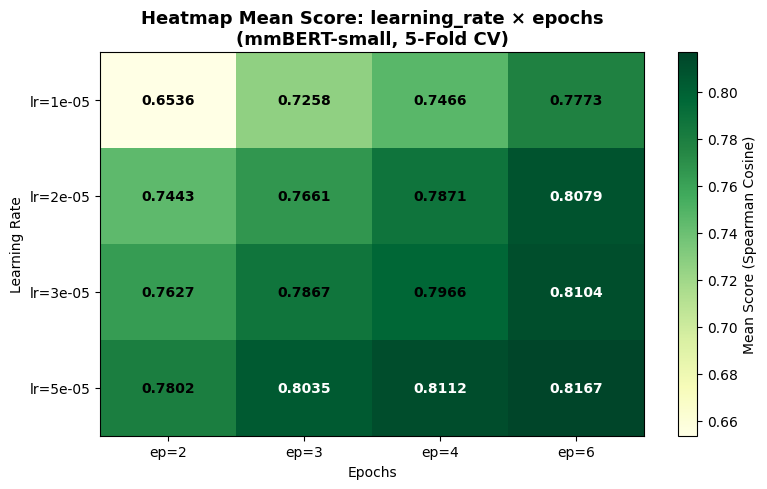

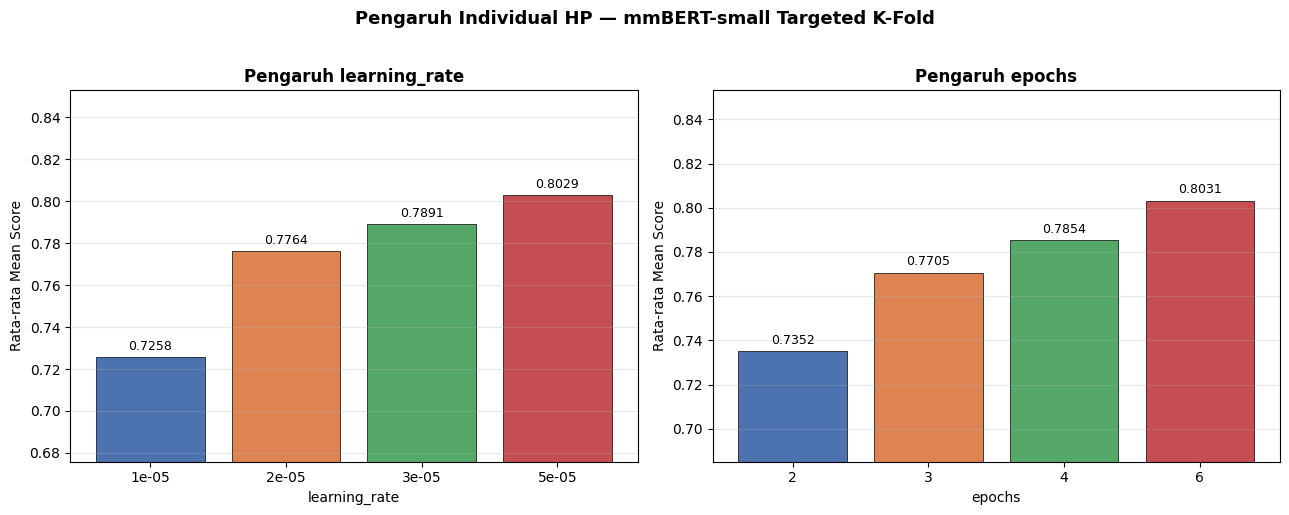

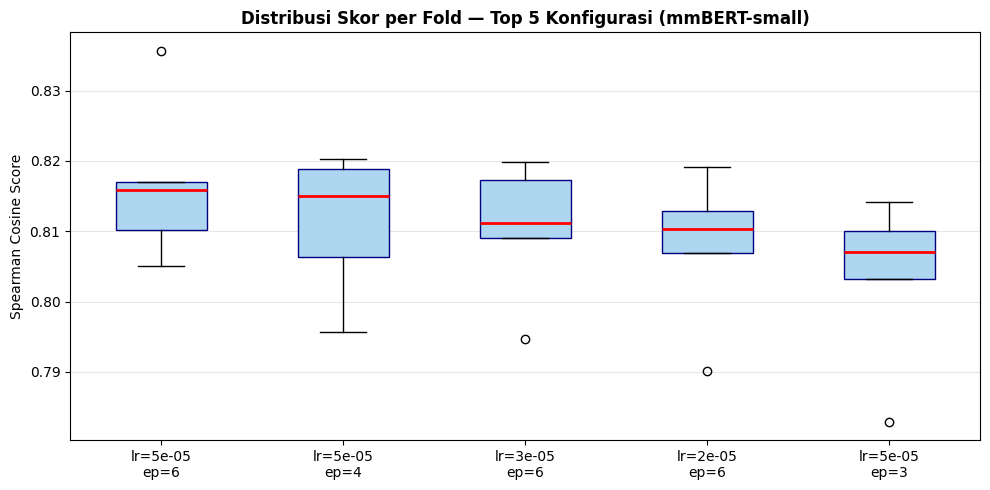

✅ Semua grafik tersimpan.


In [8]:
import matplotlib.pyplot as plt

# ── Grafik 1: Heatmap ─────────────────────────────────────────────────────
pivot = df_results.pivot_table(
    index="learning_rate", columns="epochs", values="mean_score"
)

fig1, ax1 = plt.subplots(figsize=(8, 5))
im = ax1.imshow(pivot.values, cmap="YlGn", aspect="auto")
plt.colorbar(im, ax=ax1, label="Mean Score (Spearman Cosine)")

ax1.set_xticks(range(len(pivot.columns)))
ax1.set_xticklabels([f"ep={c}" for c in pivot.columns])
ax1.set_yticks(range(len(pivot.index)))
ax1.set_yticklabels([f"lr={v:.0e}" for v in pivot.index])

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax1.text(j, i, f"{val:.4f}", ha="center", va="center",
                     fontsize=10, fontweight="bold",
                     color="black" if val < pivot.values.max()-0.02 else "white")

ax1.set_title("Heatmap Mean Score: learning_rate × epochs\n(mmBERT-small, 5-Fold CV)",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Learning Rate")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "heatmap_lr_epochs.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Grafik 2: Bar chart individual ────────────────────────────────────────
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(13, 5))

lr_summary = df_results.groupby("learning_rate")["mean_score"].mean().sort_index()
bars_lr = ax2a.bar([f"{v:.0e}" for v in lr_summary.index], lr_summary.values,
                   color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                   edgecolor="black", linewidth=0.5)
for bar, val in zip(bars_lr, lr_summary.values):
    ax2a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
              f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax2a.set_title("Pengaruh learning_rate", fontsize=12, fontweight="bold")
ax2a.set_xlabel("learning_rate"); ax2a.set_ylabel("Rata-rata Mean Score")
ax2a.set_ylim(max(0, lr_summary.min()-0.05), lr_summary.max()+0.05)
ax2a.grid(axis="y", alpha=0.3)

ep_summary = df_results.groupby("epochs")["mean_score"].mean().sort_index()
bars_ep = ax2b.bar([str(v) for v in ep_summary.index], ep_summary.values,
                   color=["#4C72B0","#DD8452","#55A868","#C44E52"],
                   edgecolor="black", linewidth=0.5)
for bar, val in zip(bars_ep, ep_summary.values):
    ax2b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
              f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax2b.set_title("Pengaruh epochs", fontsize=12, fontweight="bold")
ax2b.set_xlabel("epochs"); ax2b.set_ylabel("Rata-rata Mean Score")
ax2b.set_ylim(max(0, ep_summary.min()-0.05), ep_summary.max()+0.05)
ax2b.grid(axis="y", alpha=0.3)

plt.suptitle("Pengaruh Individual HP — mmBERT-small Targeted K-Fold",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "bar_individual_hp.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Grafik 3: Box plot top-5 ──────────────────────────────────────────────
top5 = df_results.head(5)
fold_data = [top5.iloc[i]["fold_scores"] for i in range(len(top5))]
labels = [
    f"lr={top5.iloc[i]['learning_rate']:.0e}\nep={top5.iloc[i]['epochs']}"
    for i in range(len(top5))
]
fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.boxplot(fold_data, labels=labels, patch_artist=True,
            boxprops=dict(facecolor="#AED6F1", color="navy"),
            medianprops=dict(color="red", linewidth=2))
ax3.set_title("Distribusi Skor per Fold — Top 5 Konfigurasi (mmBERT-small)",
              fontsize=12, fontweight="bold")
ax3.set_ylabel("Spearman Cosine Score")
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "boxplot_top5.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Semua grafik tersimpan.")

---
## Cell 9 — Retrain Model Terbaik (Full Dataset)

Final training menggunakan **100% data** dengan konfigurasi terbaik dari K-Fold.  
Nama file otomatis mencerminkan HP yang dipakai.

In [9]:
best_row = df_results.sort_values("mean_score", ascending=False).iloc[0]

best_config = {
    **FIXED_PARAMS,
    "learning_rate" : float(best_row["learning_rate"]),
    "epochs"        : int(best_row["epochs"]),
}

auto_name = (
    f"mmBERT-small"
    f"_bs{best_config['batch_size']}"
    f"_ep{best_config['epochs']}"
    f"_lr{best_config['learning_rate']}"
    f"_wr{best_config['warmup_ratio']}"
    f"_seq{best_config['max_seq_length']}"
)

print("🏆 Final Training — mmBERT-small Konfigurasi Terbaik")
print(f"   learning_rate  : {best_config['learning_rate']}")
print(f"   epochs         : {best_config['epochs']}")
print(f"   batch_size     : {best_config['batch_size']}  (dikunci)")
print(f"   warmup_ratio   : {best_config['warmup_ratio']}  (dikunci)")
print(f"   max_seq_length : {best_config['max_seq_length']}  (dikunci)")
print(f"   Mean Score     : {best_row['mean_score']:.5f} ± {best_row['std_score']:.5f}")
print(f"   Dataset        : {len(df_full)} triplet (full dataset)")
print(f"   Output name    : {auto_name}")

final_model = SentenceTransformer(BASE_MODEL)
final_model.max_seq_length = best_config["max_seq_length"]

final_dl     = make_dataloader(df_full, best_config["batch_size"])
final_loss   = losses.MultipleNegativesRankingLoss(model=final_model)
total_steps  = len(final_dl) * best_config["epochs"]
warmup_steps = math.ceil(total_steps * best_config["warmup_ratio"])

print(f"\n   Total steps    : {total_steps}")
print(f"   Warmup steps   : {warmup_steps}")
print("\n🔥 Memulai final training...")

os.makedirs(BEST_MODEL_PATH, exist_ok=True)
final_model.fit(
    train_objectives  = [(final_dl, final_loss)],
    epochs            = best_config["epochs"],
    warmup_steps      = warmup_steps,
    optimizer_params  = {"lr": best_config["learning_rate"]},
    show_progress_bar = True,
    output_path       = BEST_MODEL_PATH
)

with open(os.path.join(BEST_MODEL_PATH, "best_config.json"), "w") as f:
    json.dump({
        "model_name"  : BASE_MODEL,
        "auto_name"   : auto_name,
        "mean_score"  : best_row["mean_score"],
        "std_score"   : best_row["std_score"],
        "fold_scores" : best_row["fold_scores"],
        **best_config
    }, f, indent=2)

print(f"\n🎉 ALHAMDULILLAH! Model tersimpan di: '{BEST_MODEL_PATH}'")
print(f"   Nama ZIP nanti : '{auto_name}.zip'")

🏆 Final Training — mmBERT-small Konfigurasi Terbaik
   learning_rate  : 5e-05
   epochs         : 6
   batch_size     : 8  (dikunci)
   warmup_ratio   : 0.1  (dikunci)
   max_seq_length : 128  (dikunci)
   Mean Score     : 0.81675 ± 0.01037
   Dataset        : 2031 triplet (full dataset)
   Output name    : mmBERT-small_bs8_ep6_lr5e-05_wr0.1_seq128

   Total steps    : 1524
   Warmup steps   : 153

🔥 Memulai final training...


Step,Training Loss
500,1.125700
1000,0.182400
1500,0.056700


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]


🎉 ALHAMDULILLAH! Model tersimpan di: './best_model_mmbert_small_targeted'
   Nama ZIP nanti : 'mmBERT-small_bs8_ep6_lr5e-05_wr0.1_seq128.zip'


---
## Cell 10 — Ekspor ke ZIP

- `{auto_name}.zip` → model final mmBERT-small terbaik
- `hp_targeted_kfold_mmbert_logs.zip` → log JSON + 3 grafik

In [10]:
import shutil, zipfile
from IPython.display import display, FileLink

# Cek sisa disk
disk = shutil.disk_usage("/")
print(f"Sisa disk Kaggle : {disk.free / 1e9:.1f} GB")

# ZIP model terbaik
print(f"\n📦 Mengompres model: {auto_name}...")
shutil.make_archive(auto_name, "zip", BEST_MODEL_PATH)
print(f"✅ {auto_name}.zip siap.")
display(FileLink(auto_name + ".zip"))

# ZIP hanya log + grafik
print("\n📦 Mengompres log & grafik...")
log_files = ["all_results.json", "heatmap_lr_epochs.png",
             "bar_individual_hp.png", "boxplot_top5.png"]
with zipfile.ZipFile("hp_targeted_kfold_mmbert_logs.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    for f in log_files:
        fpath = os.path.join(RESULTS_PATH, f)
        if os.path.exists(fpath):
            zf.write(fpath, f)
print("✅ hp_targeted_kfold_mmbert_logs.zip siap.")
display(FileLink("hp_targeted_kfold_mmbert_logs.zip"))

print(f"\n{'='*60}")
print("  📊 RINGKASAN AKHIR — Targeted K-Fold mmBERT-small")
print(f"{'='*60}")
print(f"  Kombinasi dituning  : {len(df_results)} (lr × epochs)")
print(f"  Jumlah fold         : {K_FOLDS}")
print(f"  Mean score terbaik  : {df_results['mean_score'].max():.5f}")
print(f"  Mean score rata-rata: {df_results['mean_score'].mean():.5f}")
print(f"\n  🏆 HP TERBAIK:")
print(f"     learning_rate  : {best_config['learning_rate']}")
print(f"     epochs         : {best_config['epochs']}")
print(f"     (HP lain dikunci di nilai baseline)")
print(f"\n  Mean Score : {best_row['mean_score']:.5f} ± {best_row['std_score']:.5f}")
print(f"  Fold Scores: {best_row['fold_scores']}")
print(f"\n  File model : {auto_name}.zip")

Sisa disk Kaggle : 1491.1 GB

📦 Mengompres model: mmBERT-small_bs8_ep6_lr5e-05_wr0.1_seq128...
✅ mmBERT-small_bs8_ep6_lr5e-05_wr0.1_seq128.zip siap.


/kaggle/working/mmBERT-small_bs8_ep6_lr5e-05_wr0.1_seq128.zip


📦 Mengompres log & grafik...
✅ hp_targeted_kfold_mmbert_logs.zip siap.


/kaggle/working/hp_targeted_kfold_mmbert_logs.zip


  📊 RINGKASAN AKHIR — Targeted K-Fold mmBERT-small
  Kombinasi dituning  : 16 (lr × epochs)
  Jumlah fold         : 5
  Mean score terbaik  : 0.81675
  Mean score rata-rata: 0.77355

  🏆 HP TERBAIK:
     learning_rate  : 5e-05
     epochs         : 6
     (HP lain dikunci di nilai baseline)

  Mean Score : 0.81675 ± 0.01037
  Fold Scores: [0.80506, 0.8159, 0.81694, 0.81019, 0.83565]

  File model : mmBERT-small_bs8_ep6_lr5e-05_wr0.1_seq128.zip
